# Convolutional Neural Networks (CNNs)

We've seen that fully-connected (dense) neural networks can learn complex functions. But they have a serious problem when it comes to images.

Consider a modest 224 x 224 color image (the standard input size for many image classifiers). That's 224 x 224 x 3 = **150,528** input values. If we connect every input to a hidden layer of just 1,000 neurons, that single layer has **150 million** parameters. This is:

1. **Wasteful**: a neuron connected to every pixel treats the top-left corner as equally relevant to the bottom-right. But images have *spatial structure* -- nearby pixels are related, distant pixels usually are not.
2. **Prone to overfitting**: 150 million parameters from one layer needs an enormous training set.
3. **Slow to train**: gradient updates scale with parameter count.

We need an architecture that exploits the fact that useful patterns in images (edges, textures, shapes) are *local* and can appear *anywhere* in the image. That architecture is the **convolutional neural network**.

## The Convolution Operation

The core idea of a CNN is the **convolution** (technically cross-correlation, but everyone calls it convolution).

Instead of connecting every input to every neuron, we slide a small grid of weights -- called a **filter** or **kernel** -- across the image. At each position, we compute the element-wise product of the filter and the patch of the image it covers, then sum the results. This produces a single number. Repeating this at every position produces a 2D grid of outputs called a **feature map**.

A 3 x 3 filter has only **9 learnable parameters**, regardless of image size. The same 9 weights are reused at every position in the image.

Convolution is not a new idea. Image processing has used hand-designed filters for decades. For example:
- A **horizontal edge detector** highlights horizontal edges (boundaries between light and dark running left to right)
- A **vertical edge detector** highlights vertical edges (boundaries running top to bottom)
- A **sharpen** filter enhances contrast around edges

The innovation in CNNs is that we don't design filters by hand -- the network **learns** them from data via backpropagation.

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

input_grid = np.array([[1, 0, 2, 1, 0],
                        [0, 1, 3, 0, 1],
                        [2, 0, 1, 2, 3],
                        [1, 3, 0, 1, 0],
                        [0, 1, 2, 0, 1]])

kernel = np.array([[1,  0, -1],
                    [1,  0, -1],
                    [1,  0, -1]])

# Output is 3x3 (no padding, stride 1)
out_h, out_w = 3, 3
output_grid = np.full((out_h, out_w), np.nan)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5),
                          gridspec_kw={'width_ratios': [5, 3, 3]})

def draw_grid(ax, data, title, highlight=None, highlight_color='#FFD700'):
    ax.clear()
    h, w = data.shape
    ax.set_xlim(-0.5, w - 0.5)
    ax.set_ylim(h - 0.5, -0.5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

    for i in range(h):
        for j in range(w):
            color = 'white'
            if highlight and (i, j) in highlight:
                color = highlight_color
            ax.add_patch(patches.Rectangle((j - 0.5, i - 0.5), 1, 1,
                         facecolor=color, edgecolor='black', linewidth=1.5))
            if not np.isnan(data[i, j]):
                ax.text(j, i, str(int(data[i, j])), ha='center', va='center',
                        fontsize=14, fontweight='bold')

# Precompute all 9 frames
positions = [(r, c) for r in range(out_h) for c in range(out_w)]

def animate(frame):
    r, c = positions[frame]

    # Highlighted cells in the input
    highlight_in = set()
    for di in range(3):
        for dj in range(3):
            highlight_in.add((r + di, c + dj))

    # Compute the convolution value for this position
    region = input_grid[r:r+3, c:c+3]
    val = int(np.sum(region * kernel))
    output_grid[r, c] = val

    # Highlighted cell in the output
    highlight_out = {(r, c)}

    draw_grid(axes[0], input_grid, 'Input (5x5)', highlight=highlight_in)
    draw_grid(axes[1], kernel, 'Filter (3x3)', highlight_color='#AED6F1',
              highlight={(i, j) for i in range(3) for j in range(3)})
    draw_grid(axes[2], output_grid, 'Output (3x3)', highlight=highlight_out,
              highlight_color='#ABEBC6')

    # Show the computation below the filter
    axes[1].text(1, 3.8, '= ' + str(val), ha='center', va='center',
                 fontsize=12, fontweight='bold', color='#2E86C1')

    fig.suptitle('Step ' + str(frame + 1) + '/9: filter at row ' + str(r) + ', col ' + str(c),
                 fontsize=13, y=0.02)
    plt.tight_layout()

anim = FuncAnimation(fig, animate, frames=9, interval=1000, repeat=True)
plt.close()
HTML(anim.to_jshtml())

<Figure size 640x480 with 0 Axes>

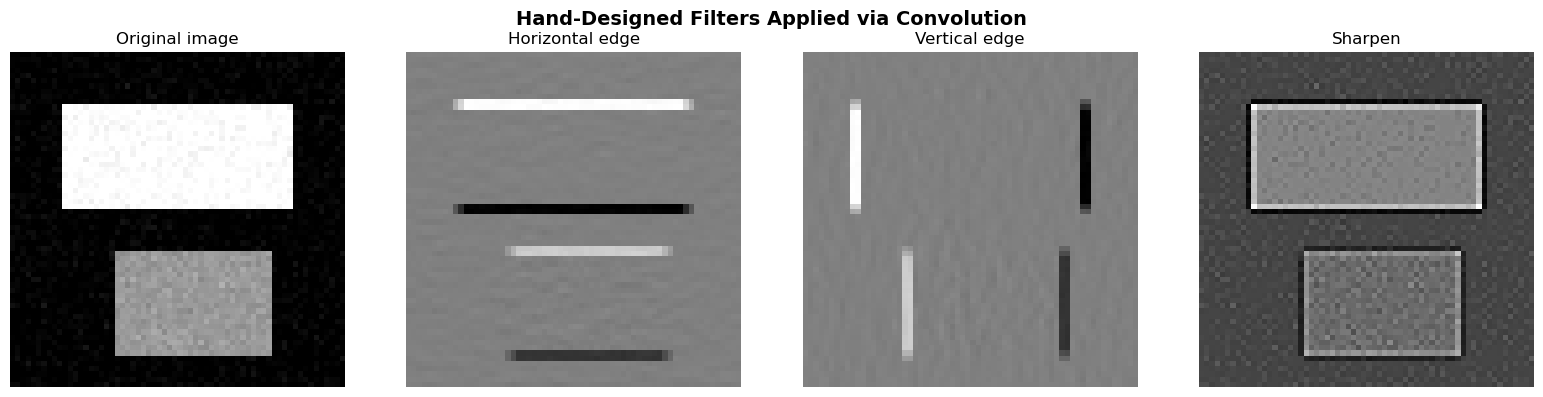

Each filter is just a 3x3 grid of numbers:

Horizontal edge:
[[-1. -1. -1.]
 [ 0.  0.  0.]
 [ 1.  1.  1.]]

Vertical edge:
[[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]]

Sharpen:
[[ 0. -1.  0.]
 [-1.  5. -1.]
 [ 0. -1.  0.]]


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate2d

# Create a synthetic image with clear edges
np.random.seed(1848)
img = np.zeros((64, 64), dtype=float)
img[10:30, 10:54] = 1.0       # large bright rectangle
img[38:58, 20:50] = 0.6       # smaller gray rectangle
img += np.random.normal(0, 0.03, img.shape)
img = np.clip(img, 0, 1)

# Three classic hand-designed filters
filters = {
    'Horizontal edge': np.array([[-1, -1, -1],
                                  [ 0,  0,  0],
                                  [ 1,  1,  1]], dtype=float),
    'Vertical edge':   np.array([[-1,  0,  1],
                                  [-1,  0,  1],
                                  [-1,  0,  1]], dtype=float),
    'Sharpen':         np.array([[ 0, -1,  0],
                                  [-1,  5, -1],
                                  [ 0, -1,  0]], dtype=float),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original image', fontsize=12)
axes[0].axis('off')

for ax, (name, filt) in zip(axes[1:], filters.items()):
    result = correlate2d(img, filt, mode='same')
    ax.imshow(result, cmap='gray')
    ax.set_title(name, fontsize=12)
    ax.axis('off')

plt.suptitle('Hand-Designed Filters Applied via Convolution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Each filter is just a 3x3 grid of numbers:")
for name, filt in filters.items():
    print()
    print(name + ":")
    print(filt)

## Stride, Padding, and Output Size

Three parameters control how the filter moves across the image:

**Stride** is how many pixels the filter moves at each step. Stride 1 means it moves one pixel at a time (most common). Stride 2 means it skips every other position, cutting the output size roughly in half.

**Padding** adds extra pixels (usually zeros) around the border of the image before applying the filter. Without padding, the output is smaller than the input because the filter can't be centered on edge pixels. With "same" padding, enough zeros are added to keep the output the same size as the input.

**Output size formula**: For an input of width $W$, filter size $F$, padding $P$, and stride $S$:

$$\text{Output size} = \left\lfloor \frac{W - F + 2P}{S} \right\rfloor + 1$$

**Example**: Input 32 x 32, filter 3 x 3, padding 1, stride 1:

$$\frac{32 - 3 + 2(1)}{1} + 1 = 32$$

Output stays 32 x 32. This is the most common setup.

**Example**: Same input, but stride 2:

$$\frac{32 - 3 + 2(1)}{2} + 1 = 16$$

Output shrinks to 16 x 16. Increasing stride is one way to reduce spatial dimensions.

You'll use this formula mainly to debug shape errors in PyTorch -- when `RuntimeError: mat1 and mat2 shapes cannot be multiplied` shows up, it usually means you miscalculated the size of the flattened feature maps.

## Pooling

After a convolutional layer, we often apply **pooling** to reduce the spatial dimensions. The most common type is **max pooling**: divide the feature map into non-overlapping windows (typically 2 x 2) and keep only the maximum value in each window.

Why pool?
- **Reduces size**: A 2 x 2 max pool cuts each spatial dimension in half, reducing the number of values by 4x.
- **Translation invariance**: Small shifts in the input change which cell within the window has the max value, but the max itself stays roughly the same. The network becomes less sensitive to the exact position of a feature.
- **Fewer parameters downstream**: Smaller feature maps mean the fully-connected layers at the end of the network have fewer inputs.

**Average pooling** takes the mean instead of the max. It's less common in intermediate layers but is sometimes used near the end of a network (called "global average pooling") to replace a fully-connected layer entirely.

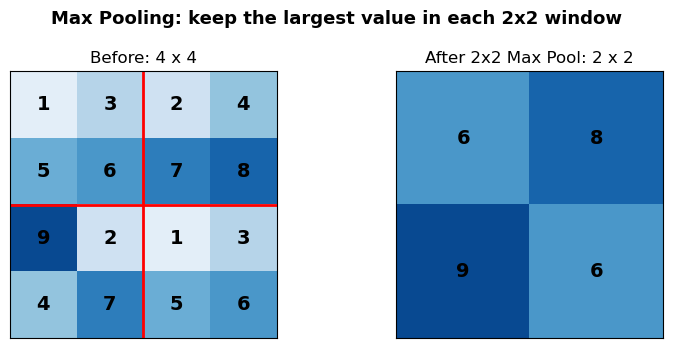

Each 2x2 window -> its maximum value:
  Top-left:     max(1,3,5,6) = 6
  Top-right:    max(2,4,7,8) = 8
  Bottom-left:  max(9,2,4,7) = 9
  Bottom-right: max(1,3,5,6) = 6


In [39]:
import numpy as np
import matplotlib.pyplot as plt

# A small example to see max pooling in action
grid = np.array([[1, 3, 2, 4],
                 [5, 6, 7, 8],
                 [9, 2, 1, 3],
                 [4, 7, 5, 6]], dtype=float)

# 2x2 max pooling
pooled = np.array([[grid[0:2, 0:2].max(), grid[0:2, 2:4].max()],
                   [grid[2:4, 0:2].max(), grid[2:4, 2:4].max()]])

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

# Before pooling
ax = axes[0]
ax.imshow(grid, cmap='Blues', vmin=0, vmax=10)
for i in range(4):
    for j in range(4):
        ax.text(j, i, str(int(grid[i,j])), ha='center', va='center', fontsize=14, fontweight='bold')
ax.set_title('Before: 4 x 4', fontsize=12)
ax.set_xticks([]); ax.set_yticks([])
# Draw pool boundaries
ax.axhline(1.5, color='red', linewidth=2)
ax.axvline(1.5, color='red', linewidth=2)

# After pooling
ax = axes[1]
ax.imshow(pooled, cmap='Blues', vmin=0, vmax=10)
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(int(pooled[i,j])), ha='center', va='center', fontsize=14, fontweight='bold')
ax.set_title('After 2x2 Max Pool: 2 x 2', fontsize=12)
ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Max Pooling: keep the largest value in each 2x2 window', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Each 2x2 window -> its maximum value:")
print("  Top-left:     max(1,3,5,6) =", int(pooled[0,0]))
print("  Top-right:    max(2,4,7,8) =", int(pooled[0,1]))
print("  Bottom-left:  max(9,2,4,7) =", int(pooled[1,0]))
print("  Bottom-right: max(1,3,5,6) =", int(pooled[1,1]))

## The CNN Architecture Pattern

A typical CNN stacks several *convolutional blocks*, each consisting of:

**Conv -> ReLU -> Pool**

repeated two or more times, followed by:

**Flatten -> Fully Connected -> Output**

As data flows through the network:
- **Spatial dimensions shrink** (pooling cuts them in half each time)
- **Number of channels grows** (each conv layer typically uses more filters than the last)
- **Features become more abstract**: early layers detect simple patterns like edges and color gradients. Middle layers combine those into textures and parts (e.g., fur, wheels). Deep layers recognize whole objects (e.g., "cat face", "car").

This hierarchy -- edges to textures to parts to objects -- is one of the most important ideas in deep learning. The network doesn't need to be told to look for edges; it discovers them because they're useful for the classification task.

**Example architecture for a 32 x 32 color image:**

```
Input:  32 x 32 x 3  (height x width x color channels)
   |
Conv1:  32 x 32 x 16  (16 filters, 3x3, padding 1)
ReLU
Pool:   16 x 16 x 16  (2x2 max pool)
   |
Conv2:  16 x 16 x 32  (32 filters, 3x3, padding 1)
ReLU
Pool:    8 x  8 x 32  (2x2 max pool)
   |
Flatten: 2048  (= 8 * 8 * 32)
   |
FC:      128
ReLU
   |
Output:  10   (one per class)
```

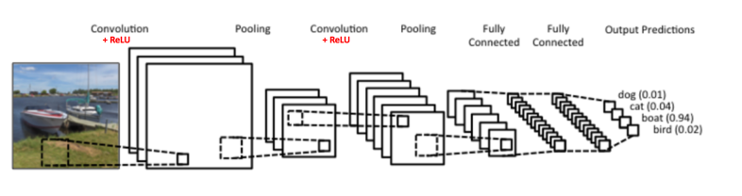

## Why CNNs Work: Three Key Properties

CNNs are so effective on images because of three properties built into their design:

**1. Local connectivity.**
Each neuron in a convolutional layer is connected to only a small *local region* of the input (the size of the filter), not the entire image. This matches the structure of images: a pixel is most informative about its neighbors, not about pixels on the other side of the image.

**2. Parameter sharing.**
The same filter weights are applied at every position in the image. A 3 x 3 filter has 9 parameters regardless of whether the image is 32 x 32 or 1024 x 1024. This is why a CNN can have orders of magnitude fewer parameters than a fully-connected network on the same input.

**3. Translation equivariance.**
Because the same filter is applied everywhere, if an object moves in the image, its feature map shifts by the same amount -- but the *features detected* don't change. A vertical edge is a vertical edge whether it appears on the left or right side of the image. (Pooling adds approximate *translation invariance* on top of this: small shifts may not change the pooled output at all.)

As we'll see below, these three properties let a CNN use ~11x fewer parameters than a regular neural net on an "easy" image dataset while matching its accuracy, and dramatically outperform a regular neural net on a more complex image dataset.

**Terminology**: When we start talking about other types of neural nets besides "regular" ones, we will often use the term "multilayer perceptron" (MLP) to refer to the "regular" neural network.  An MLP is just the standard fully-connected neural network you've already been building -- an input layer, one or more hidden layers, and an output layer, with every neuron connected to every neuron in the next layer. "MLP" is the traditional name for this architecture. 

The term "perceptron" dates back to 1958, when Frank Rosenblatt built one of the first neural network models -- a single neuron that could learn to classify inputs into two categories. The name was meant to evoke the idea of a machine that "perceives." A multi-layer perceptron, then, is just multiple layers of these perceptrons stacked together, which is exactly what a fully-connected neural network is.

When applied to images, the MLP flattens the entire image into a single vector of pixel values (e.g., 28 x 28 = 784 numbers) and treats each pixel as an independent input feature. This means it has no awareness of which pixels are neighbors -- a pixel in the top-left corner is treated the same as the pixel right next to it, which is treated the same as a pixel on the other side of the image.

## Working with Image Datasets in PyTorch

Up to now, our datasets have been small enough to pass entirely through the model in a single call: `y_hat = model(X_train)`. Image datasets are much larger (MNIST has 60,000 images, CIFAR-10 has 50,000), so we need two new tools:

**`torchvision.datasets`** provides standard image datasets (MNIST, CIFAR-10, etc.) that download automatically. Each image needs to be converted to a tensor, which is done by passing `transform=transforms.ToTensor()`. We also apply `transforms.Normalize(...)` to center the pixel values around zero, which helps training converge faster (same idea as feature scaling in linear regression).

**`DataLoader`** wraps a dataset and feeds it to the model in **batches** (e.g., 64 images at a time) rather than all at once. The training loop changes slightly:

```python
# Before (all data at once):
for epoch in range(num_epochs):
    y_hat = model(X_train)
    loss = loss_fn(y_hat, y_train)
    ...

# Now (one batch at a time):
for epoch in range(num_epochs):
    for X_batch, y_batch in train_loader:
        y_hat = model(X_batch)
        loss = loss_fn(y_hat, y_batch)
        ...
```

The inner loop iterates over all batches. One full pass through all the batches is still one epoch.

## Comparing MLP and CNN on MNIST

Let's start with handwritten digits (MNIST). The images are small (28 x 28), grayscale, and centered. We'll train an MLP and a simple CNN, then compare parameter counts and accuracy.

As you'll see, both do very well on MNIST -- the task is simple enough that an MLP can handle it. The interesting comparison will come in the next section.

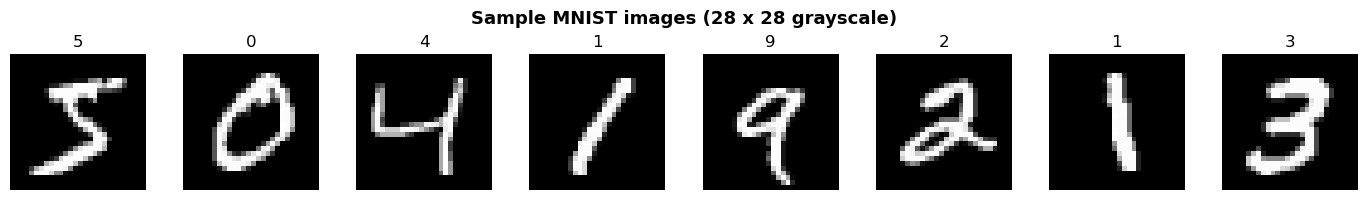

Training on MNIST (5 epochs each, device=cpu)
   MLP  Parameters: 101770  Test accuracy: 0.9798
   CNN  Parameters: 9098  Test accuracy: 0.9852


In [40]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
torch.manual_seed(1848)

# Load MNIST
# Normalize using the precomputed mean and std of the MNIST training set.
# These are standard values you'll see in most MNIST examples.
transform = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize((0.1307,), (0.3081,))])
train_data = datasets.MNIST('data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST('data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

# Show a few examples
raw_data = datasets.MNIST('data', train=True, download=True,
                           transform=transforms.ToTensor())
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    img, label = raw_data[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(str(label), fontsize=12)
    ax.axis('off')
plt.suptitle('Sample MNIST images (28 x 28 grayscale)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# MLP: flatten the 28x28 image into 784 numbers, then a hidden layer
mlp = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

# CNN: two conv layers with pooling, then a fully-connected output
# Conv2d arguments: (in_channels, out_channels, kernel_size, padding)
#   in_channels:  how many channels the input has (1 for grayscale, 3 for RGB)
#   out_channels: how many filters to learn (each produces one feature map)
#   kernel_size:  filter size (3 means 3x3)
#   padding:      zeros added around the border (1 preserves spatial size with a 3x3 filter)
cnn = nn.Sequential(
    nn.Conv2d(1, 8, 3, padding=1),   # 28x28x1  -> 28x28x8  (8 filters, each 3x3x1)
    nn.ReLU(),
    nn.MaxPool2d(2),                  # -> 14x14x8
    nn.Conv2d(8, 16, 3, padding=1),  # -> 14x14x16 (16 filters, each 3x3x8)
    nn.ReLU(),
    nn.MaxPool2d(2),                  # -> 7x7x16
    nn.Flatten(),                     # -> 784
    nn.Linear(16 * 7 * 7, 10)
).to(device)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def train_and_eval(model, name, epochs=5):
    # Momentum keeps a running average of past gradients, so updates are
    # smoother and faster than plain SGD. 0.9 is the standard default.
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    loss_fn   = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        # model.train() tells PyTorch we're training. Some layers (like dropout
        # and batch norm) behave differently during training vs evaluation.
        # Our simple models don't use those layers, but it's good practice.
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss_fn(model(X_batch), y_batch).backward()
            optimizer.step()

    # model.eval() switches to evaluation mode, and torch.no_grad() tells
    # PyTorch not to track gradients, since we're just measuring accuracy.
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            # model() returns shape (batch_size, 10) with one score per class.
            # .argmax(1) picks the column index (class) with the highest score
            # for each image. == y_batch checks which predictions are correct.
            correct += (model(X_batch).argmax(1) == y_batch).sum().item()
            total   += len(y_batch)
    acc = correct / total
    print("  ", name, " Parameters:", count_params(model), " Test accuracy:", acc)
    return acc

print("Training on MNIST (5 epochs each, device=" + str(device) + ")")
print("=" * 55)
mlp_acc = train_and_eval(mlp, "MLP")
cnn_acc = train_and_eval(cnn, "CNN")
print("=" * 55)

### How many parameters does the CNN have?

ReLU, MaxPool2d, and Flatten have no learnable parameters, so we only need to count the conv and linear layers.

**Conv2d(1, 8, 3)**: 8 filters, each 3×3×1 weights + 1 bias = 8 × 10 = **80**

**Conv2d(8, 16, 3)**: 16 filters, each 3×3×8 weights + 1 bias = 16 × 73 = **1,168**

**Linear(784, 10)**: 784×10 weights + 10 biases = **7,850**

**Total: 80 + 1,168 + 7,850 = 9,098**

Notice that the two conv layers together account for only about 1,250 parameters. The bulk of the parameters (7,850) are in the final fully-connected layer. This is typical of CNNs: conv layers are cheap because the same small filter is reused across the entire image (parameter sharing), and the FC layer at the end is the expensive part.

## Comparing MLP and CNN on CIFAR-10

MNIST is grayscale, 28 x 28, and centered. It's almost *too* easy. Let's try something harder: **CIFAR-10**, which contains 32 x 32 color photographs of 10 categories (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck).

These are real images with complex backgrounds, varying positions, and three color channels. This is where the MLP's inability to exploit spatial structure becomes a serious handicap.

/opt/anaconda3/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


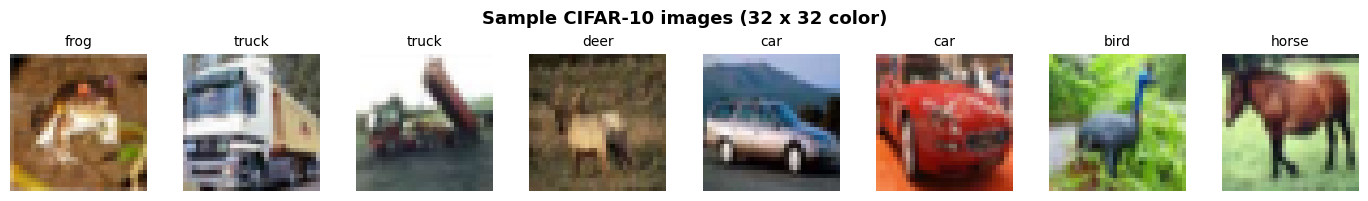

Training on CIFAR-10 (10 epochs each, device=cpu)
   MLP  Parameters: 820874  Test accuracy: 0.5164
   CNN  Parameters: 268650  Test accuracy: 0.6829


In [41]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
torch.manual_seed(1848)

# Load CIFAR-10
# Normalize using the precomputed mean and std of the CIFAR-10 training set (per RGB channel).
transform = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize((0.4914, 0.4822, 0.4465),
                                                      (0.2470, 0.2435, 0.2616))])
train_data = datasets.CIFAR10('data', train=True,  download=True, transform=transform)
test_data  = datasets.CIFAR10('data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

classes = ('airplane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# Show a few examples
raw_data = datasets.CIFAR10('data', train=True, download=True,
                             transform=transforms.ToTensor())
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    img, label = raw_data[i]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(classes[label], fontsize=10)
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 images (32 x 32 color)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# MLP: flatten 32x32x3 = 3072 inputs
mlp = nn.Sequential(
    nn.Flatten(),
    nn.Linear(32*32*3, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

# CNN: two conv layers with pooling, then fully-connected
cnn = nn.Sequential(
    nn.Conv2d(3, 16, 3, padding=1),   # 32x32x3  -> 32x32x16
    nn.ReLU(),
    nn.MaxPool2d(2),                   # -> 16x16x16
    nn.Conv2d(16, 32, 3, padding=1),  # -> 16x16x32
    nn.ReLU(),
    nn.MaxPool2d(2),                   # -> 8x8x32
    nn.Flatten(),                      # -> 2048
    nn.Linear(32 * 8 * 8, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def train_and_eval(model, name, epochs=10):
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    loss_fn   = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss_fn(model(X_batch), y_batch).backward()
            optimizer.step()

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            correct += (model(X_batch).argmax(1) == y_batch).sum().item()
            total   += len(y_batch)
    acc = correct / total
    print("  ", name, " Parameters:", count_params(model), " Test accuracy:", acc)
    return model, acc

print("Training on CIFAR-10 (10 epochs each, device=" + str(device) + ")")
print("=" * 55)
_, mlp_acc = train_and_eval(mlp, "MLP")
cnn_model, cnn_acc = train_and_eval(cnn, "CNN")
print("=" * 55)

## Visualizing What the CNN Learned

We can peek inside the trained CNN by looking at its **feature maps** (activations) for a specific input image. Each feature map shows *where* in the image a particular filter responds most strongly. Bright regions in a feature map mean that filter detected something it was looking for at that location.

Below, we pass a single CIFAR-10 image through the first convolutional layer and display all 16 feature maps side by side. You'll see that different filters pick up on different aspects of the image -- some respond to edges, others to color boundaries or textures.

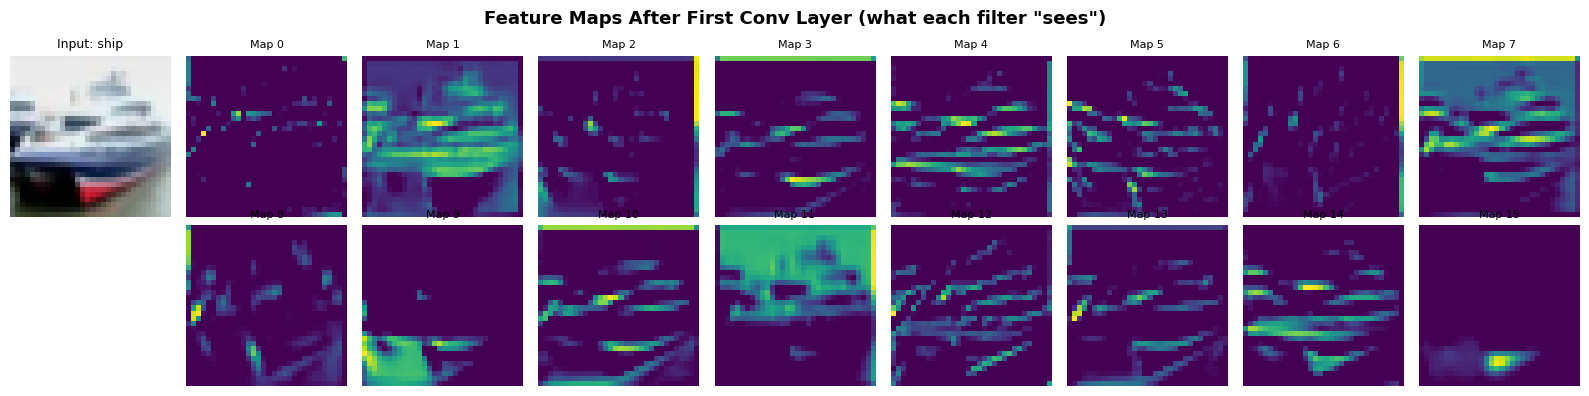

In [42]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms

# Use the CIFAR CNN we just trained (cnn_model)
# Show feature maps for a sample image
raw_data = datasets.CIFAR10('data', train=False, transform=transforms.ToTensor())
sample_img, sample_label = raw_data[1]

classes = ('airplane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# Get activations after conv1 + relu (layers [0] and [1] in the Sequential)
normalize = transforms.Normalize((0.4914, 0.4822, 0.4465),
                                  (0.2470, 0.2435, 0.2616))
x = normalize(sample_img).unsqueeze(0).to(next(cnn_model.parameters()).device)

cnn_model.eval()
with torch.no_grad():
    # Run through first conv + relu only
    activations = cnn_model[1](cnn_model[0](x))  # conv -> relu

act = activations[0].cpu().numpy()  # (16, 32, 32)

fig, axes = plt.subplots(2, 9, figsize=(16, 4))
# First cell: original image
axes[0, 0].imshow(sample_img.permute(1, 2, 0).numpy())
axes[0, 0].set_title('Input: ' + classes[sample_label], fontsize=9)
axes[0, 0].axis('off')
axes[1, 0].axis('off')

# Remaining cells: 16 feature maps
for i in range(16):
    row, col = divmod(i, 8)
    ax = axes[row, col + 1]
    ax.imshow(act[i], cmap='viridis')
    ax.set_title('Map ' + str(i), fontsize=8)
    ax.axis('off')

plt.suptitle('Feature Maps After First Conv Layer (what each filter "sees")',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



## Landmark CNN Architectures

The core ideas (convolution, pooling, stacking layers) have remained the same since the late 1990s. What has changed is **depth**, **training techniques**, and **architectural tricks**. Here are four landmarks:

**LeNet-5 (LeCun et al., 1998)**
The original CNN. Two conv layers followed by fully-connected layers, trained on handwritten digits. It proved that learned convolutional filters could outperform hand-engineered features. At the time, it was used by the US Postal Service to read ZIP codes.

**AlexNet (Krizhevsky et al., 2012)**
The paper that started the modern deep learning era. AlexNet won the ImageNet competition by a huge margin, beating the previous best (which used hand-crafted features) by over 10 percentage points. Key innovations: much deeper than LeNet (5 conv layers), used ReLU instead of sigmoid, used dropout to prevent overfitting, and trained on GPUs.

**VGG (Simonyan & Zisserman, 2014)**
VGG's key insight was simplicity: use only 3x3 filters and just keep stacking more layers (up to 19). It showed that *depth* matters more than filter size. The architecture is very uniform: Conv-Conv-Pool repeated, which makes it easy to understand. VGG-16 (16 layers) is still widely used as a feature extractor.

**ResNet (He et al., 2015)**
The problem with very deep networks is that gradients vanish, making training difficult. ResNet introduced **skip connections** (also called residual connections): each block adds its input directly to its output, so the network only needs to learn the *difference* (residual) from the identity mapping. This made it possible to train networks with 50, 101, or even 152 layers, dramatically improving accuracy.

## Transfer Learning

In practice, very few people train a CNN from scratch. Instead, the standard approach is **transfer learning**:

1. Start with a model pretrained on a large dataset (usually ImageNet, which has 1.2 million images across 1,000 classes).
2. **Freeze** the convolutional layers (don't update their weights). These layers have already learned general-purpose features like edges, textures, and shapes that transfer well to most image tasks.
3. **Replace** the final fully-connected layer with a new one that has the right number of outputs for your task.
4. **Train** only the new layer (and optionally fine-tune the last few conv layers) on your dataset.

This works because early layers learn features that are universal across image tasks. An edge detector learned on ImageNet is just as useful for medical images or satellite photos.

Transfer learning has two practical benefits:
- **Less data required**: you only need to train the final layer(s), which have far fewer parameters.
- **Better accuracy**: the pretrained features are much better than what you'd learn from scratch on a small dataset.

The code below uses **ResNet-18**, a well-known CNN architecture (one of the landmark architectures mentioned above). PyTorch's `torchvision.models` library provides this architecture with weights that were already trained on ImageNet. What we do is: load the pretrained ResNet-18 (getting all its conv layers with their learned weights), freeze those conv layers so they don't change, replace the final fully-connected layer with a new one that outputs 10 classes (for CIFAR-10) instead of the original 1,000 (for ImageNet), and then train only that new final layer on our data. We compare this against training the same ResNet-18 architecture from scratch with random weights, using only 2,000 training images.

Note: pretrained models from `torchvision.models` are defined using Python classes rather than `nn.Sequential`, which is why we access layers by name (like `model.fc`) rather than by index. The important thing is that `model.fc` is the final fully-connected layer, and we replace it with a new one.

In [43]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import numpy as np

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
torch.manual_seed(1848)

# CIFAR-10 resized to 96x96 so pretrained features (learned on 224x224 images) transfer better.
# Using a small subset to keep training fast on CPU.
transform = transforms.Compose([
    transforms.Resize(96),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                          (0.2470, 0.2435, 0.2616))
])

full_train = datasets.CIFAR10('data', train=True,  download=True, transform=transform)
full_test  = datasets.CIFAR10('data', train=False, download=True, transform=transform)

np.random.seed(1848)
train_idx = np.random.choice(len(full_train), 2000, replace=False)
test_idx  = np.random.choice(len(full_test),  500, replace=False)

train_loader = DataLoader(Subset(full_train, train_idx), batch_size=64, shuffle=True)
test_loader  = DataLoader(Subset(full_test,  test_idx),  batch_size=64, shuffle=False)

def evaluate(model):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            correct += (model(X_batch).argmax(1) == y_batch).sum().item()
            total   += len(y_batch)
    return correct / total

# ── Pretrained ResNet-18: freeze everything, replace last layer ─────────
model_pretrained = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all layers
for param in model_pretrained.parameters():
    param.requires_grad = False

# Replace final FC layer: was 512 -> 1000 (ImageNet), now 512 -> 10 (CIFAR-10)
model_pretrained.fc = nn.Linear(512, 10)
model_pretrained = model_pretrained.to(device)

# Only train the new FC layer
optimizer = torch.optim.SGD(model_pretrained.fc.parameters(), lr=0.01, momentum=0.9)
loss_fn   = nn.CrossEntropyLoss()

print("Transfer learning: pretrained ResNet-18, training only the last layer...")
print("(Using 2,000 training images to simulate a small dataset)")
print()
for epoch in range(3):
    model_pretrained.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss_fn(model_pretrained(X_batch), y_batch).backward()
        optimizer.step()
    acc = evaluate(model_pretrained)
    print("  Epoch", epoch + 1, "/ 3 -- Test accuracy:", acc)

# ── From scratch: same architecture, random weights ─────────────────────
model_scratch = models.resnet18(weights=None, num_classes=10).to(device)
optimizer2 = torch.optim.SGD(model_scratch.parameters(), lr=0.01, momentum=0.9)

print()
print("From scratch: same ResNet-18, random initialization...")
for epoch in range(3):
    model_scratch.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer2.zero_grad()
        loss_fn(model_scratch(X_batch), y_batch).backward()
        optimizer2.step()
    acc = evaluate(model_scratch)
    print("  Epoch", epoch + 1, "/ 3 -- Test accuracy:", acc)

pretrained_acc = evaluate(model_pretrained)
scratch_acc    = evaluate(model_scratch)

print()
print("=" * 50)
print("Pretrained + fine-tuned: ", pretrained_acc)
print("Trained from scratch:   ", scratch_acc)
print("=" * 50)
print()


Transfer learning: pretrained ResNet-18, training only the last layer...
(Using 2,000 training images to simulate a small dataset)

  Epoch 1 / 3 -- Test accuracy: 0.672
  Epoch 2 / 3 -- Test accuracy: 0.676
  Epoch 3 / 3 -- Test accuracy: 0.668

From scratch: same ResNet-18, random initialization...
  Epoch 1 / 3 -- Test accuracy: 0.192
  Epoch 2 / 3 -- Test accuracy: 0.27
  Epoch 3 / 3 -- Test accuracy: 0.356

Pretrained + fine-tuned:  0.668
Trained from scratch:    0.356



With only 2,000 images and 3 epochs, the pretrained model
gets a large head start. Its conv layers already know useful
features learned from 1.2 million ImageNet images.